In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
import statsmodels.tsa.stattools as sm
%matplotlib inline

# In sample 

In [2]:
TIME = "10y" # Not used in general, just an option 
START = "2014-01-01" # May need to tweak based on when stock introduced - some are quite old!!
END = "2025-01-01" # End of training data, and start of OOS
PRICE = "Close" # Can do High, Low, Open, etc. - Close is normally same as Open for subsequent day, with some drift 
THRESHOLD = 2 # The z-score threshold, which will pretty dramatically affect Sharpe ratio - tuning too finely for in-sample normally cooks OOS
T_MAX = 500 # Max threshold swept to, *100 (i.e. t_max is actually T_MAX/100)
TRANSACTION_PRICE = 0.05 # Flat fee per transaction -  could adjust per size of trade...? 

A_stock = "V" # Formely needed to have larger stock value as B, but solved
B_stock = "MA" 



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


2768 2768


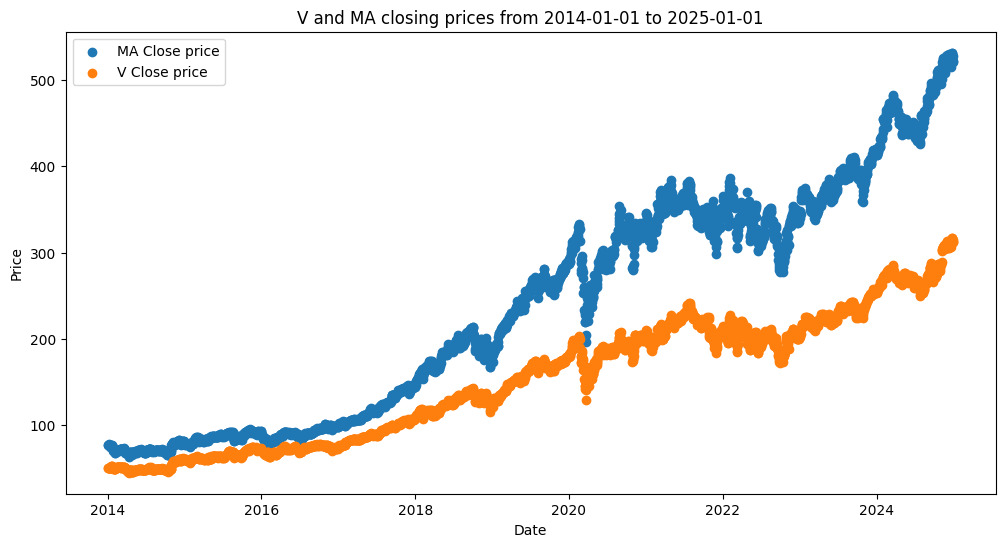

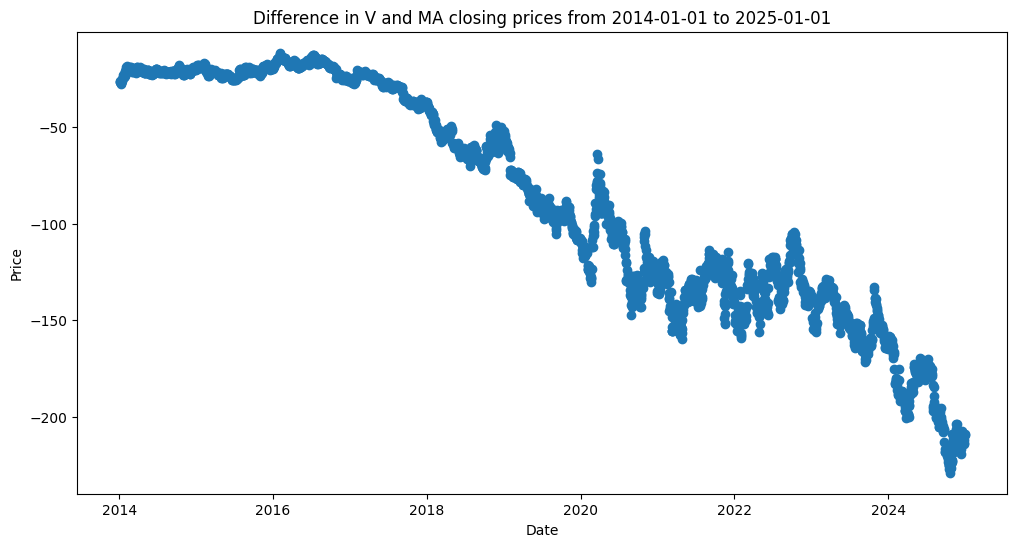

In [3]:
B_data = yf.download(B_stock, start=START, end=END)
A_data = yf.download(A_stock, start=START, end=END)


# Logic for swapping stocks as needed to keep signs in check 
if A_data[PRICE].values.flatten().mean() > B_data[PRICE].values.flatten().mean():
    temp = A_data
    A_data = B_data
    B_data = temp

# Making sure there is data for the entire length of time
print(len(B_data.index), len(A_data.index))
time_data = B_data.index



plt.figure(figsize=(12, 6))
plt.scatter(time_data, B_data[PRICE], label=f"{B_stock} {PRICE} price")
plt.scatter(time_data, A_data[PRICE], label=f"{A_stock} {PRICE} price")
plt.title(f"{A_stock} and {B_stock} closing prices from {START} to {END}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.scatter(time_data, (A_data[PRICE].values.flatten() - B_data[PRICE].values.flatten()), label="Difference")
plt.title(f"Difference in {A_stock} and {B_stock} closing prices from {START} to {END}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

## Coint tests

In [4]:
# Checking the cointegration value - lower p-value is better (Null is no cointegration)
_, p_value, _ = sm.coint(B_data[PRICE].values.flatten(), A_data[PRICE].values.flatten())
print(f"Cointegration p-value: {p_value:.4f}")

Cointegration p-value: 0.0006


## Trading

In [5]:
# Linear regression on stocks, params[0] is the linear term, params[1] is the constant term  
params = np.polyfit(B_data[PRICE].values.flatten(), A_data[PRICE].values.flatten(), deg=1)
print(params)

[ 0.55127902 20.1957457 ]


[]

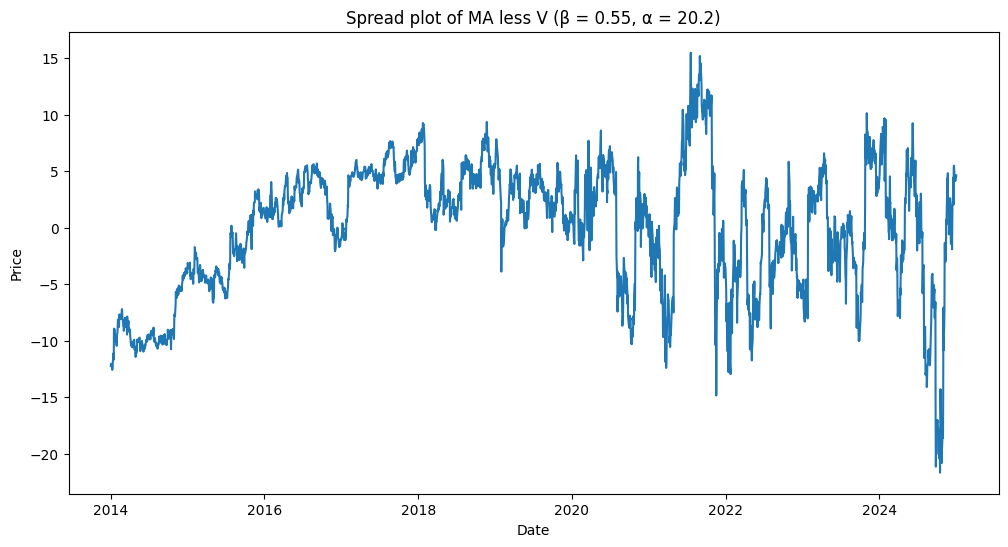

In [6]:
# The spread has the form A - β*B - α (where α is normally just very close to 0) - β determines the relative weight of holdings needed for balance 
spread = A_data[PRICE].values.flatten() - params[0]*B_data[PRICE].values.flatten() - params[1]

plt.figure(figsize=(12, 6))
plt.plot(time_data, spread, label="Spread")
plt.title(f"Spread plot of {B_stock} less {A_stock} (\u03B2 = {round(params[0], 2)}, \u03b1 = {round(params[1], 2)})")
plt.xlabel("Date")
plt.ylabel("Price")
plt.plot()

2.8955643278085005e-14 5.759057597498962


[]

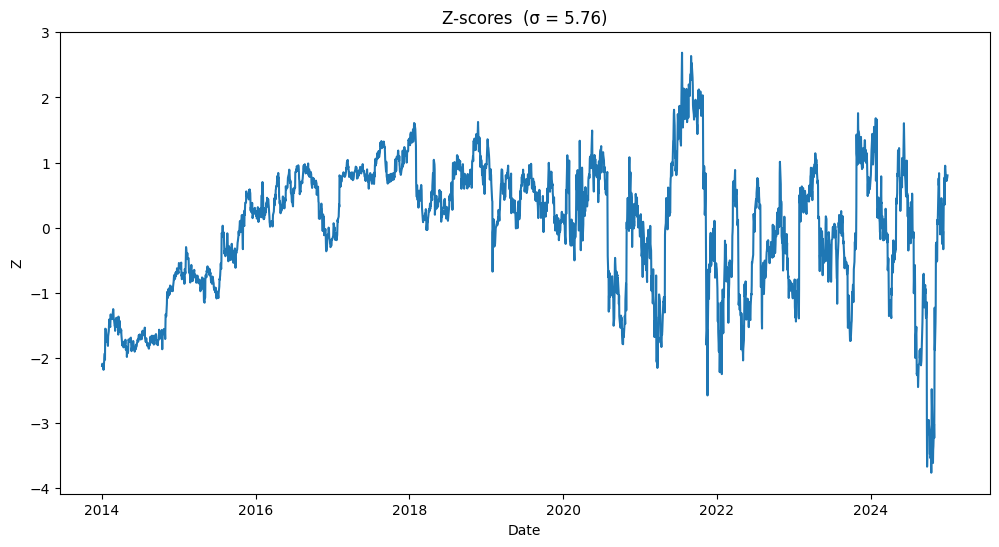

In [7]:
print(np.mean(spread), np.std(spread)) # Hoping for mean close to 0, standard deviation gives scaling to extract z-value 

sigma = np.std(spread)

z_scores = spread / sigma

plt.figure(figsize=(12, 6))
plt.plot(time_data, z_scores, label="Spread")
plt.title(f"Z-scores  (\u03C3 = {round(sigma, 2)})")
plt.xlabel("Date")
plt.ylabel("Z")
plt.plot()

In [8]:
# Simple logic for signal-generation - could be scalar, but the sharp threshold is a good baseline. Not the confusion about "long" vs. "short" - need to be careful on signs
def signal(z, threshold):
    if z > threshold: return -1 # Short the spread
    elif z < -threshold: return 1 # Long the spread
    return 0 # Flat

signals = list(map(lambda z: signal(z, threshold=THRESHOLD), z_scores))

# plt.figure(figsize=(12, 6))
# plt.plot(time_data, z_scores, label="Z scores")
# plt.title(f"Z-scores  (\u03C3 = {round(sigma, 2)})")
# plt.xlabel("Date")
# plt.ylabel("Z")
# plt.plot()

[]

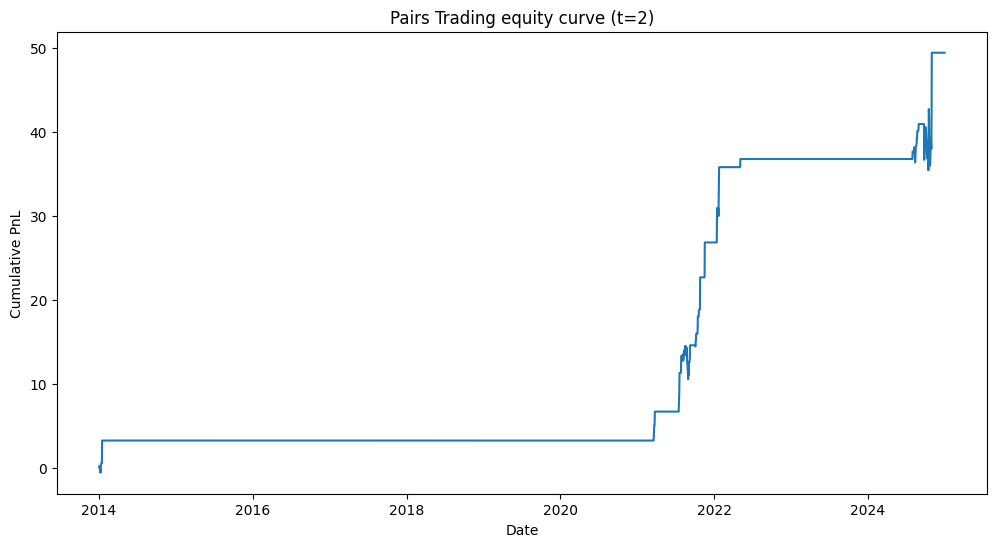

In [9]:
# First term gives PnL per transaction (lossy if signal is negative - short by selling - vice versa if long)
# Second term is transaction cost - constant per transaction, regardless of direction and size 
PnL = signals[:-1] * np.diff(spread) - (np.abs(signals[:-1])*TRANSACTION_PRICE) 

plt.figure(figsize=(12, 6))
plt.plot(time_data[:-1], np.cumsum(PnL))
plt.title(f"Pairs Trading equity curve (t={THRESHOLD})")
plt.ylabel("Cumulative PnL")
plt.xlabel("Date")
plt.plot()


In [10]:
print(f"In-sample Sharpe ratio is {np.mean(PnL) / np.std(PnL) * np.sqrt(252)}")

In-sample Sharpe ratio is 0.8636357152981754


3.77


/tmp/ipykernel_72989/565983062.py:10: RuntimeWarning: invalid value encountered in scalar divide
  sharpes.append(np.mean(PnL) / np.std(PnL) * np.sqrt(252))


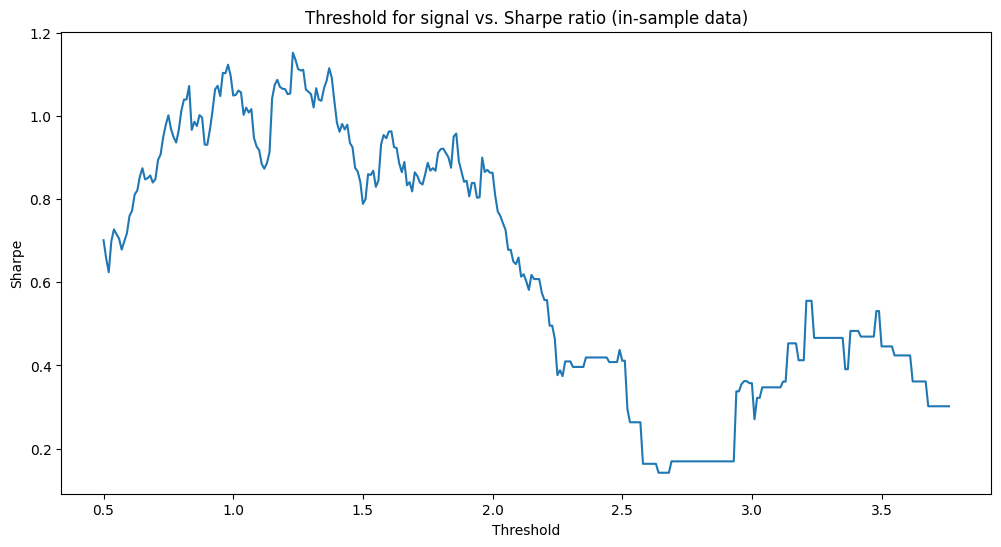

In [11]:
# Threshold sweep logic, should swap to np.arange or linspace. Pops out the Sharpe ratio per threshold, and the optimal threshold 

ts = []
sharpes = []

for t in range(50, T_MAX, 1):
    ts.append(t/100)
    signals = list(map(lambda e: signal(e, threshold=t/100), z_scores))
    PnL = signals[:-1] * np.diff(spread) - (np.abs(signals[:-1])*TRANSACTION_PRICE)
    sharpes.append(np.mean(PnL) / np.std(PnL) * np.sqrt(252))



plt.figure(figsize=(12, 6))
plt.plot(ts, sharpes)
plt.title(f"Threshold for signal vs. Sharpe ratio (in-sample data)")
plt.ylabel("Sharpe")
plt.xlabel("Threshold")
plt.plot();

print(ts[np.argmax(sharpes)])

# Out of sample (all logic exactly the same)

In [12]:
B_test_data = yf.download(B_stock, start=END, end=None)
A_test_data = yf.download(A_stock, start=END, end=None)

if A_test_data[PRICE].values.flatten().mean() > B_test_data[PRICE].values.flatten().mean():
    temp = A_test_data
    A_test_data = B_test_data
    B_test_data = temp

print(len(B_test_data.index), len(A_test_data.index))

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

342 342


In [13]:
_, p_value, _ = sm.coint(B_test_data[PRICE].values.flatten(), A_test_data[PRICE].values.flatten())
print(f"Cointegration p-value: {p_value:.10f}")

Cointegration p-value: 0.6254882992


[]

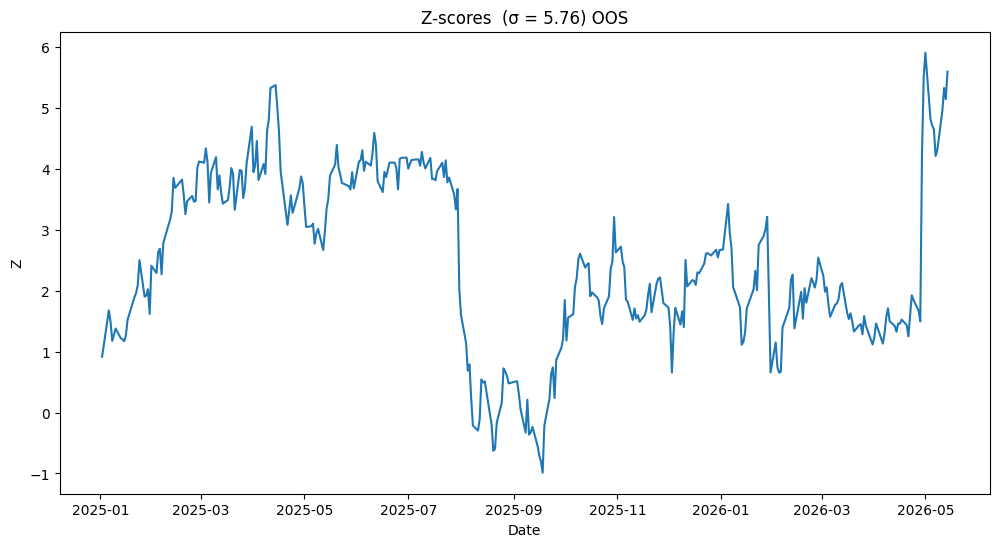

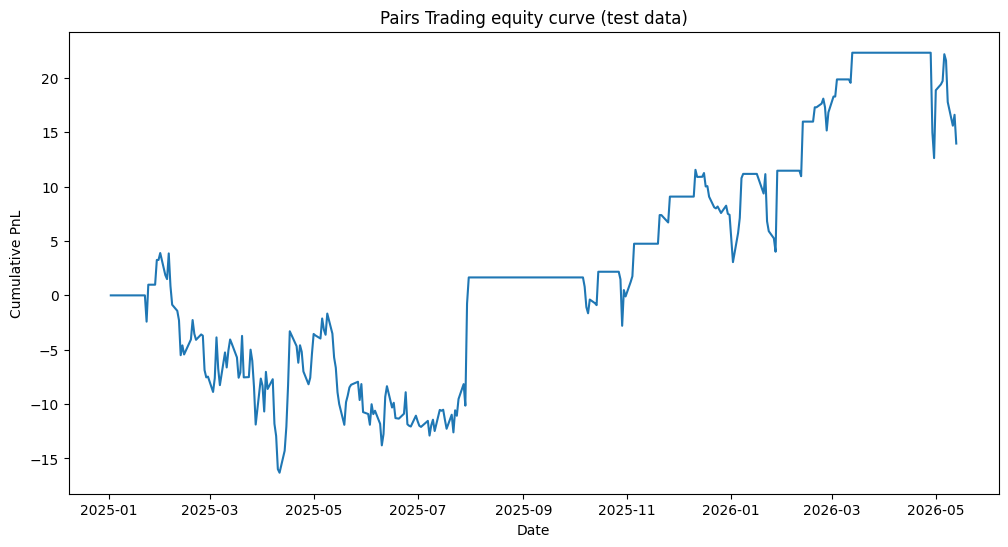

In [14]:
test_time_data = A_test_data.index

test_spread = A_test_data[PRICE].values.flatten() - params[0] * B_test_data[PRICE].values.flatten() - params[1]

test_z_scores = test_spread / sigma

test_signals = list(map(lambda e: signal(e, threshold=THRESHOLD), test_z_scores))

test_PnL = test_signals[:-1] * np.diff(test_spread) - (np.abs(test_signals[:-1])*TRANSACTION_PRICE)

plt.figure(figsize=(12, 6))
plt.plot(test_time_data, test_z_scores, label="Spread")
plt.title(f"Z-scores  (\u03C3 = {round(sigma, 2)}) OOS")
plt.xlabel("Date")
plt.ylabel("Z")
plt.plot()

plt.figure(figsize=(12, 6))
plt.plot(test_time_data[:-1], np.cumsum(test_PnL))
plt.title(f"Pairs Trading equity curve (test data)")
plt.ylabel("Cumulative PnL")
plt.xlabel("Date")
plt.plot()

In [15]:
print(np.mean(test_PnL) / np.std(test_PnL) * np.sqrt(252))

0.3986528726999132


4.31


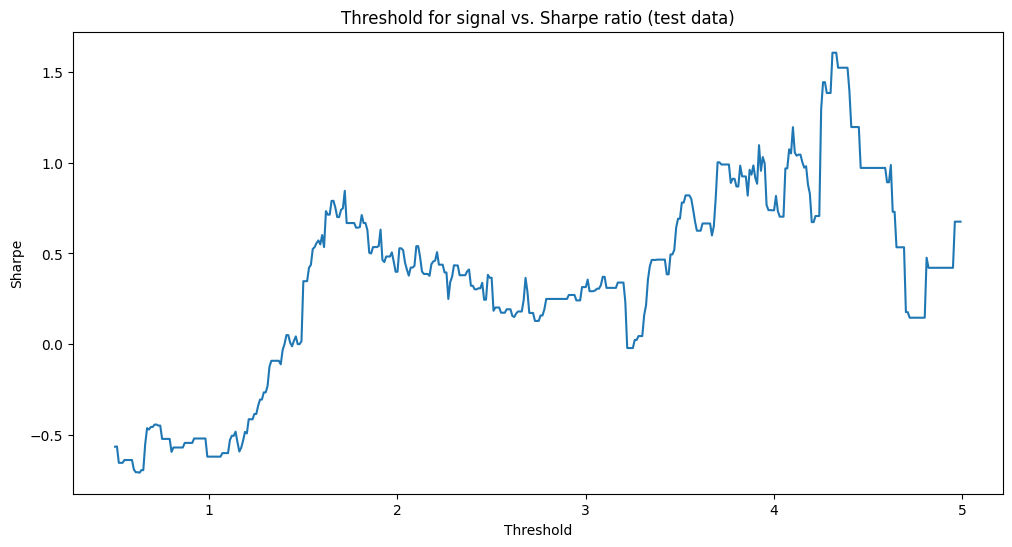

In [16]:
ts = []
sharpes = []

for t in range(50, T_MAX, 1):
    ts.append(t/100)
    test_signals = list(map(lambda e: signal(e, threshold=t/100), test_z_scores))
    test_PnL = test_signals[:-1] * np.diff(test_spread) - (np.abs(test_signals[:-1])*TRANSACTION_PRICE)
    sharpes.append(np.mean(test_PnL) / np.std(test_PnL) * np.sqrt(252))



plt.figure(figsize=(12, 6))
plt.plot(ts, sharpes)
plt.title(f"Threshold for signal vs. Sharpe ratio (test data)")
plt.ylabel("Sharpe")
plt.xlabel("Threshold")
plt.plot()

print(ts[np.argmax(sharpes)])


# All time

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

3110 3110


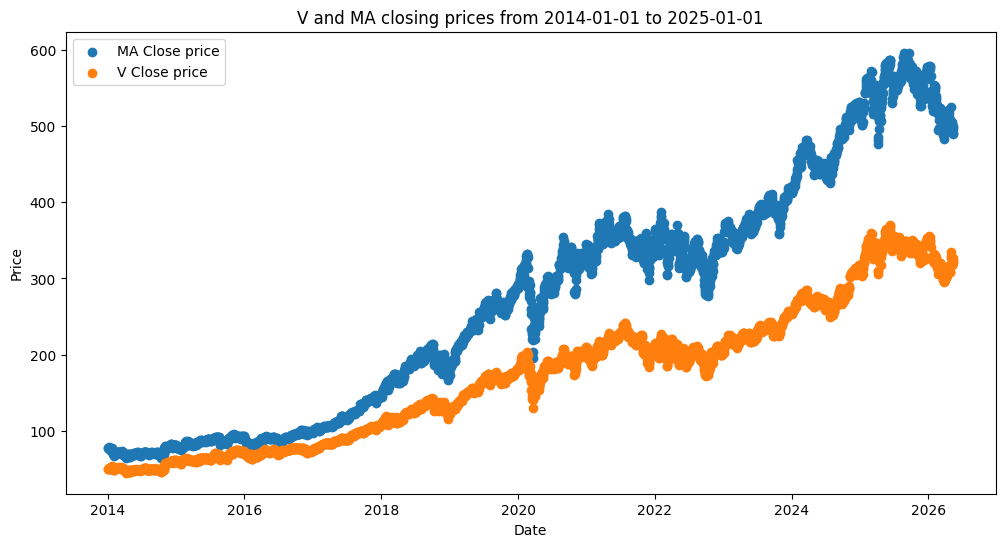

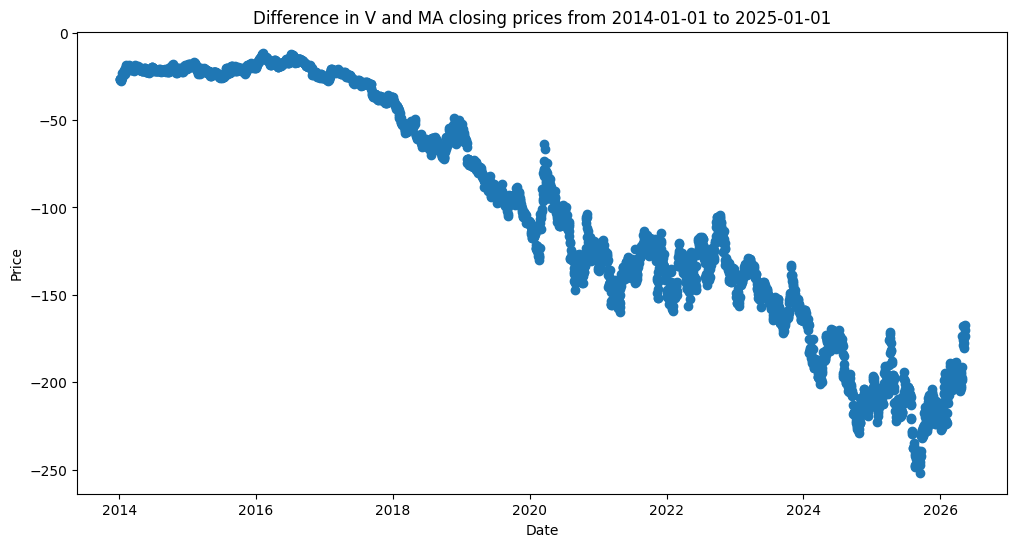

In [17]:
B_data = yf.download(B_stock, start=START, end=None)
A_data = yf.download(A_stock, start=START, end=None)

print(len(B_data.index), len(A_data.index))
time_data = B_data.index

plt.figure(figsize=(12, 6))
plt.scatter(time_data, B_data[PRICE], label=f"{B_stock} {PRICE} price")
plt.scatter(time_data, A_data[PRICE], label=f"{A_stock} {PRICE} price")
plt.title(f"{A_stock} and {B_stock} closing prices from {START} to {END}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()

plt.figure(figsize=(12, 6))
plt.scatter(time_data, (A_data[PRICE].values.flatten() - B_data[PRICE].values.flatten()), label="Difference")
plt.title(f"Difference in {A_stock} and {B_stock} closing prices from {START} to {END}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()